# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Muhammad Irzam Hafis Fabiansyah | 5054251024 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# download latest
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Path to dataset files:", path)

Path to dataset files: /home/irzam/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1


In [2]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.
df = pd.read_csv(path + '/insurance.csv')

In [3]:
# Tampilkan beberapa baris pertama dataset.
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Tampilkan informasi dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
# Periksa missing value.
display(df.isnull().sum())

display(df.duplicated().sum())
df = df.drop_duplicates()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

np.int64(1)

In [6]:
# Tampilkan statistik deskriptif fitur numerik.
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
display(df.sex.value_counts())
display(df.smoker.value_counts())
display(df.region.value_counts())

sex
male      675
female    662
Name: count, dtype: int64

smoker
no     1063
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.

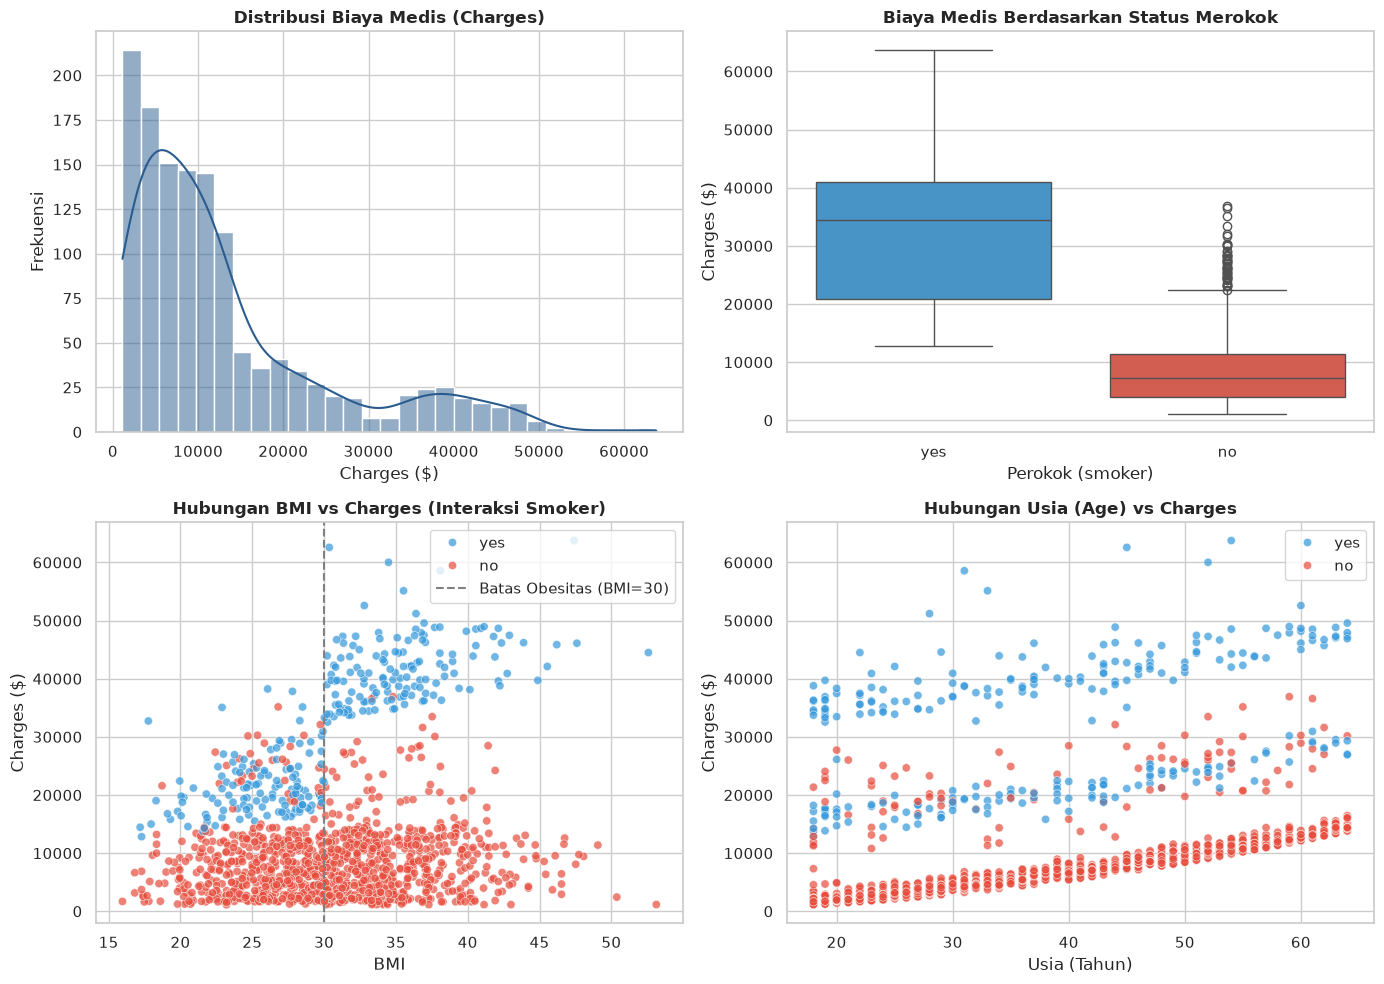

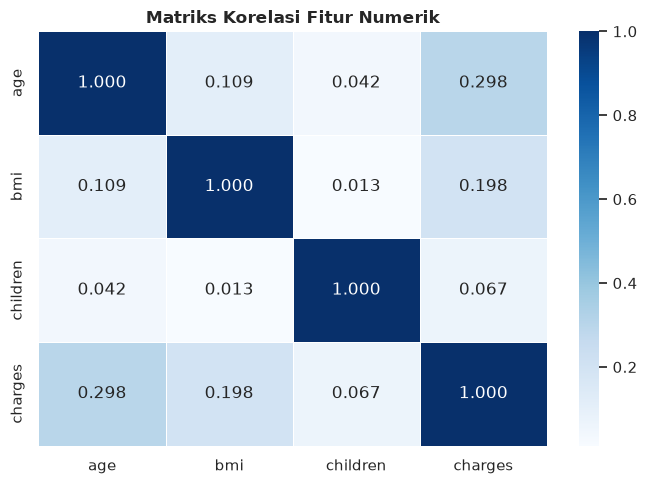

In [8]:
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi target charges
sns.histplot(df['charges'], kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title("Distribusi Biaya Medis (Charges)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Charges ($)")
axes[0, 0].set_ylabel("Frekuensi")

# 2. Pengaruh status merokok terhadap charges
sns.boxplot(data=df, x='smoker', y='charges', hue='smoker', palette=['#3498db', '#e74c3c'], legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Biaya Medis Berdasarkan Status Merokok", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Perokok (smoker)")
axes[0, 1].set_ylabel("Charges ($)")

# 3. Hubungan BMI vs charges dengan perbedaan status perokok
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette=['#3498db', '#e74c3c'], alpha=0.7, ax=axes[1, 0])
axes[1, 0].axvline(x=30, color='gray', linestyle='--', label='Batas Obesitas (BMI=30)')
axes[1, 0].set_title("Hubungan BMI vs Charges (Interaksi Smoker)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("BMI")
axes[1, 0].set_ylabel("Charges ($)")
axes[1, 0].legend()

# 4. Hubungan Umur vs charges dengan perbedaan status perokok
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette=['#3498db', '#e74c3c'], alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title("Hubungan Usia (Age) vs Charges", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Usia (Tahun)")
axes[1, 1].set_ylabel("Charges ($)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Matriks korelasi antar fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', linewidths=0.5)
plt.title("Matriks Korelasi Fitur Numerik", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Temuan Utama dari Exploratory Data Analysis (EDA):
1. **Distribusi Target (`charges`)**: Bersifat *right-skewed* (condong ke kanan) dengan ekor panjang di angka tinggi, di mana sebagian besar tagihan berada di bawah \$10,000, namun terdapat kelompok tagihan tinggi hingga mencapai lebih dari \$60,000.
2. **Pengaruh Signifikan `smoker`**: Status perokok merupakan faktor pembeda biaya medis paling signifikan. Median tagihan medis perokok jauh lebih tinggi (> \$30,000) dibandingkan non-perokok (< \$10,000).
3. **Efek Interaksi `bmi` dan `smoker`**: Pada non-perokok, kenaikan BMI hanya menaikkan biaya medis secara marginal. Namun pada perokok, terdapat lonjakan eksponensial tajam saat BMI melampaui batas obesitas (BMI > 30).
4. **Hubungan Usia (`age`)**: Biaya medis memiliki tren linear meningkat seiring pertambahan usia pada kedua kelompok (perokok dan non-perokok).

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.

In [9]:
# Pisahkan fitur (X) dan target (y).
X = df.drop(columns=['charges'])
y = df['charges']

print(f"Dimensi fitur (X) : {X.shape}")
print(f"Dimensi target (y): {y.shape}")

Dimensi fitur (X) : (1337, 6)
Dimensi target (y): (1337,)


In [10]:
# Identifikasi kolom numerik dan kategorikal.
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

print(f"Fitur Numerik   : {numeric_features}")
print(f"Fitur Kategorikal: {categorical_features}")

Fitur Numerik   : ['age', 'bmi', 'children']
Fitur Kategorikal: ['sex', 'smoker', 'region']


In [11]:
# Bagi data menjadi train set dan test set.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Jumlah sampel Train: {len(X_train)} (80%)")
print(f"Jumlah sampel Test : {len(X_test)} (20%)")

Jumlah sampel Train: 1069 (80%)
Jumlah sampel Test : 268 (20%)


In [12]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Preprocessing dengan scaling (StandardScaler) untuk Linear, Poly, Ridge, Lasso, SVR
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# 2. Preprocessing tanpa scaling (passthrough) khusus untuk Decision Tree Regressor
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Fit dan transformasi pada train set serta test set
X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

X_train_tree = preprocessor_tree.fit_transform(X_train)
X_test_tree = preprocessor_tree.transform(X_test)

feature_names = preprocessor_scaled.get_feature_names_out()
print("Nama fitur setelah encoding:")
for name in feature_names:
    print(f" - {name}")
print(f"\nDimensi X_train hasil preprocessing: {X_train_scaled.shape}")

Nama fitur setelah encoding:
 - num__age
 - num__bmi
 - num__children
 - cat__sex_male
 - cat__smoker_yes
 - cat__region_northwest
 - cat__region_southeast
 - cat__region_southwest

Dimensi X_train hasil preprocessing: (1069, 8)


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.

In [13]:
# Inisialisasi dan latih Linear Regression.
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("Linear Regression berhasil dilatih.")
print(f"Intercept: {lr_model.intercept_:.2f}")
for feat, coef in zip(feature_names, lr_model.coef_):
    print(f"Koefisien {feat:30s}: {coef:10.2f}")

Linear Regression berhasil dilatih.
Intercept: 8947.95
Koefisien num__age                      :    3472.98
Koefisien num__bmi                      :    1927.83
Koefisien num__children                 :     636.50
Koefisien cat__sex_male                 :    -101.54
Koefisien cat__smoker_yes               :   23077.76
Koefisien cat__region_northwest         :    -391.76
Koefisien cat__region_southeast         :    -838.92
Koefisien cat__region_southwest         :    -659.14


In [14]:
# Lakukan prediksi pada test set.
y_pred_lr = lr_model.predict(X_test_scaled)
print("Sampel 5 prediksi pertama vs aktual:")
pred_comp_lr = pd.DataFrame({'Aktual': y_test.values[:5], 'Prediksi': y_pred_lr[:5]})
display(pred_comp_lr)

Sampel 5 prediksi pertama vs aktual:


,Aktual,Prediksi
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657


## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.

In [15]:
# Buat fitur polynomial dan latih model.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, root_mean_squared_error

# Eksperimen degree 1, 2, dan 3
poly_degrees = [1, 2, 3]
poly_exp = []

for deg in poly_degrees:
    poly_trans = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_p = poly_trans.fit_transform(X_train_scaled)
    X_te_p = poly_trans.transform(X_test_scaled)
    
    m = LinearRegression()
    m.fit(X_tr_p, y_train)
    
    tr_r2 = r2_score(y_train, m.predict(X_tr_p))
    te_r2 = r2_score(y_test, m.predict(X_te_p))
    poly_exp.append({
        'Degree': deg,
        'Jumlah Fitur': X_tr_p.shape[1],
        'Train R²': tr_r2,
        'Test R²': te_r2,
        'RMSE Test': root_mean_squared_error(y_test, m.predict(X_te_p))
    })

print("Hasil Eksperimen Pemilihan Degree Polynomial:")
display(pd.DataFrame(poly_exp))

# Memilih degree=2 karena memberikan peningkatan performa optimal tanpa overfitting berlebih
best_poly_degree = 2
poly_features = PolynomialFeatures(degree=best_poly_degree, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train_scaled)
X_test_poly = poly_features.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
print(f"Model Polynomial Regression (degree={best_poly_degree}) berhasil dilatih.")

Hasil Eksperimen Pemilihan Degree Polynomial:


,Degree,Jumlah Fitur,Train R²,Test R²,RMSE Test
0,1,8,0.729906,0.806929,5956.342894
1,2,44,0.834026,0.882530,4646.056793
2,3,164,0.847116,0.870918,4870.269998


Model Polynomial Regression (degree=2) berhasil dilatih.


In [16]:
# Lakukan prediksi pada test set.
y_pred_poly = poly_model.predict(X_test_poly)
print("Sampel 5 prediksi pertama Polynomial Regression:")
display(pd.DataFrame({'Aktual': y_test.values[:5], 'Prediksi': y_pred_poly[:5]}))

Sampel 5 prediksi pertama Polynomial Regression:


,Aktual,Prediksi
0,8688.85885,8353.843089
1,5708.86700,6542.119190
2,11436.73815,14316.736746
3,38746.35510,35908.934065
4,4463.20510,5652.797364


## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.

In [17]:
# Inisialisasi dan latih Ridge Regression.
from sklearn.linear_model import Ridge

# Eksperimen variasi nilai alpha
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
ridge_exp = []

for a in alphas:
    r_model = Ridge(alpha=a, random_state=42)
    r_model.fit(X_train_scaled, y_train)
    ridge_exp.append({
        'Alpha': a,
        'Train R²': r2_score(y_train, r_model.predict(X_train_scaled)),
        'Test R²': r2_score(y_test, r_model.predict(X_test_scaled)),
        'RMSE Test': root_mean_squared_error(y_test, r_model.predict(X_test_scaled))
    })

print("Hasil Eksperimen Nilai Alpha pada Ridge Regression:")
display(pd.DataFrame(ridge_exp))

# Memilih alpha=1.0 sebagai regularisasi L2 optimal
best_alpha_ridge = 1.0
ridge_model = Ridge(alpha=best_alpha_ridge, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
print(f"Model Ridge Regression (alpha={best_alpha_ridge}) berhasil dilatih.")

Hasil Eksperimen Nilai Alpha pada Ridge Regression:


,Alpha,Train R²,Test R²,RMSE Test
0,0.001,0.729906,0.806928,5956.358241
1,0.010,0.729906,0.806919,5956.496377
2,0.100,0.729906,0.806829,5957.879296
3,1.000,0.729884,0.805921,5971.861741
4,10.000,0.727945,0.795884,6124.340276
5,50.000,0.697336,0.741047,6898.122737
6,100.000,0.643719,0.671529,7769.074021
7,500.000,0.375608,0.377961,10691.276544
8,1000.000,0.254786,0.252492,11720.030338


Model Ridge Regression (alpha=1.0) berhasil dilatih.


In [18]:
# Lakukan prediksi pada test set.
y_pred_ridge = ridge_model.predict(X_test_scaled)
print("Sampel 5 prediksi pertama Ridge Regression:")
display(pd.DataFrame({'Aktual': y_test.values[:5], 'Prediksi': y_pred_ridge[:5]}))

Sampel 5 prediksi pertama Ridge Regression:


,Aktual,Prediksi
0,8688.85885,8170.649135
1,5708.86700,5767.791213
2,11436.73815,14379.971933
3,38746.35510,31637.008765
4,4463.20510,9003.528284


## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.

In [19]:
# Inisialisasi dan latih Lasso Regression.
from sklearn.linear_model import Lasso

# Eksperimen variasi nilai alpha
lasso_alphas = [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
lasso_exp = []

for a in lasso_alphas:
    l_model = Lasso(alpha=a, random_state=42)
    l_model.fit(X_train_scaled, y_train)
    lasso_exp.append({
        'Alpha': a,
        'Train R²': r2_score(y_train, l_model.predict(X_train_scaled)),
        'Test R²': r2_score(y_test, l_model.predict(X_test_scaled)),
        'RMSE Test': root_mean_squared_error(y_test, l_model.predict(X_test_scaled))
    })

print("Hasil Eksperimen Nilai Alpha pada Lasso Regression:")
display(pd.DataFrame(lasso_exp))

# Memilih alpha=5.0 sebagai regularisasi L1 optimal
best_alpha_lasso = 5.0
lasso_model = Lasso(alpha=best_alpha_lasso, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
print(f"Model Lasso Regression (alpha={best_alpha_lasso}) berhasil dilatih.")

Hasil Eksperimen Nilai Alpha pada Lasso Regression:


,Alpha,Train R²,Test R²,RMSE Test
0,0.01,0.729906,0.806928,5956.355547
1,0.10,0.729906,0.806920,5956.469554
2,1.00,0.729905,0.806846,5957.614852
3,5.00,0.729893,0.806508,5962.825426
4,10.00,0.729856,0.806067,5969.616715
5,50.00,0.729229,0.802232,6028.354178
6,100.00,0.728550,0.798840,6079.831670
7,500.00,0.712577,0.764689,6575.701295


Model Lasso Regression (alpha=5.0) berhasil dilatih.


In [20]:
# Lakukan prediksi pada test set.
y_pred_lasso = lasso_model.predict(X_test_scaled)
print("Sampel 5 prediksi pertama Lasso Regression:")
display(pd.DataFrame({'Aktual': y_test.values[:5], 'Prediksi': y_pred_lasso[:5]}))

Sampel 5 prediksi pertama Lasso Regression:


,Aktual,Prediksi
0,8688.85885,8112.414670
1,5708.86700,5752.681836
2,11436.73815,14359.718952
3,38746.35510,31734.224566
4,4463.20510,8989.280312


## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.

In [21]:
# Inisialisasi dan latih Decision Tree Regressor.
from sklearn.tree import DecisionTreeRegressor

# Eksperimen parameter max_depth dan min_samples_leaf
depth_candidates = [2, 3, 4, 5, 6, 8, None]
min_leaf_candidates = [1, 5, 10, 20]

dt_experiments = []
for depth in depth_candidates:
    for leaf in min_leaf_candidates:
        dt = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=leaf, random_state=42)
        dt.fit(X_train_tree, y_train)
        
        train_r2 = r2_score(y_train, dt.predict(X_train_tree))
        test_r2 = r2_score(y_test, dt.predict(X_test_tree))
        rmse = root_mean_squared_error(y_test, dt.predict(X_test_tree))
        
        dt_experiments.append({
            'max_depth': 'None' if depth is None else str(depth),
            'min_samples_leaf': leaf,
            'Train R²': train_r2,
            'Test R²': test_r2,
            'Test RMSE': rmse
        })

df_dt_exp = pd.DataFrame(dt_experiments)
print("Top 8 Konfigurasi Decision Tree Berdasarkan Test R²:")
display(df_dt_exp.sort_values(by='Test R²', ascending=False).head(8))

# Memilih konfigurasi terbaik yang seimbang: max_depth=4, min_samples_leaf=20
dt_model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train_tree, y_train)
print("Model Decision Tree Regressor (max_depth=4, min_samples_leaf=20) berhasil dilatih.")

Top 8 Konfigurasi Decision Tree Berdasarkan Test R²:


,max_depth,min_samples_leaf,Train R²,Test R²,Test RMSE
11,4,20,0.854799,0.901067,4263.737204
15,5,20,0.861572,0.900843,4268.578467
14,5,10,0.865151,0.899555,4296.198087
9,4,5,0.855242,0.897219,4345.875200
10,4,10,0.855242,0.897219,4345.875200
8,4,1,0.855242,0.897219,4345.875200
13,5,5,0.865731,0.895776,4376.275501
18,6,10,0.872361,0.895756,4376.699182


Model Decision Tree Regressor (max_depth=4, min_samples_leaf=20) berhasil dilatih.


In [22]:
# Lakukan prediksi pada test set.
y_pred_dt = dt_model.predict(X_test_tree)
print("Sampel 5 prediksi pertama Decision Tree Regressor:")
display(pd.DataFrame({'Aktual': y_test.values[:5], 'Prediksi': y_pred_dt[:5]}))

Sampel 5 prediksi pertama Decision Tree Regressor:


,Aktual,Prediksi
0,8688.85885,11016.035202
1,5708.86700,7357.271700
2,11436.73815,11016.035202
3,38746.35510,40778.860983
4,4463.20510,7357.271700


## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.

In [23]:
# Inisialisasi dan latih SVR.
from sklearn.svm import SVR

# Eksperimen variasi nilai C dan epsilon pada kernel RBF
# Catatan: Nilai C default (C=1) sangat kecil untuk skala tagihan medis (ribuan dolar),
# sehingga eksperimen menguji rentang C dari kecil hingga besar.
svr_experiments = []

c_values = [1, 100, 1000, 5000, 10000, 15000, 20000]
eps_values = [0.1, 10.0, 50.0, 100.0]

for c in c_values:
    for eps in eps_values:
        svr_temp = SVR(kernel='rbf', C=c, epsilon=eps)
        svr_temp.fit(X_train_scaled, y_train)
        
        tr_r2 = r2_score(y_train, svr_temp.predict(X_train_scaled))
        te_r2 = r2_score(y_test, svr_temp.predict(X_test_scaled))
        rmse = root_mean_squared_error(y_test, svr_temp.predict(X_test_scaled))
        
        svr_experiments.append({
            'C': c,
            'epsilon': eps,
            'Train R²': tr_r2,
            'Test R²': te_r2,
            'Test RMSE': rmse
        })

df_svr_exp = pd.DataFrame(svr_experiments)
print("Top 8 Konfigurasi SVR Berdasarkan Test R²:")
display(df_svr_exp.sort_values(by='Test R²', ascending=False).head(8))

# Memilih C=15000 dan epsilon=50
best_c_svr = 15000
best_eps_svr = 50.0
svr_model = SVR(kernel='rbf', C=best_c_svr, epsilon=best_eps_svr)
svr_model.fit(X_train_scaled, y_train)
print(f"Model SVR (kernel='rbf', C={best_c_svr}, epsilon={best_eps_svr}) berhasil dilatih.")

Top 8 Konfigurasi SVR Berdasarkan Test R²:


,C,epsilon,Train R²,Test R²,Test RMSE
27,20000,100.0,0.832405,0.868846,4909.209371
26,20000,50.0,0.831048,0.868546,4914.818244
25,20000,10.0,0.829908,0.868432,4916.947329
24,20000,0.1,0.829630,0.868363,4918.240469
23,15000,100.0,0.829573,0.865351,4974.186326
22,15000,50.0,0.828345,0.864999,4980.692610
21,15000,10.0,0.827253,0.864630,4987.494902
20,15000,0.1,0.826997,0.864581,4988.395403


Model SVR (kernel='rbf', C=15000, epsilon=50.0) berhasil dilatih.


In [24]:
# Lakukan prediksi pada test set.
y_pred_svr = svr_model.predict(X_test_scaled)
print("Sampel 5 prediksi pertama SVR:")
display(pd.DataFrame({'Aktual': y_test.values[:5], 'Prediksi': y_pred_svr[:5]}))

Sampel 5 prediksi pertama SVR:


,Aktual,Prediksi
0,8688.85885,8729.865332
1,5708.86700,6630.892799
2,11436.73815,11463.510302
3,38746.35510,33834.243451
4,4463.20510,4474.254456


# 4. Evaluasi Model

In [25]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_predictions = {
    'Linear Regression': y_pred_lr,
    'Polynomial Regression (deg=2)': y_pred_poly,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Decision Tree Regressor': y_pred_dt,
    'Support Vector Regression': y_pred_svr
}

eval_records = []
for name, preds in model_predictions.items():
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    eval_records.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R² Score': r2
    })

eval_df = pd.DataFrame(eval_records).sort_values(by='R² Score', ascending=False).reset_index(drop=True)

# Tampilkan tabel perbandingan numerik yang rapi
eval_df_display = eval_df.copy()
eval_df_display['MAE'] = eval_df_display['MAE'].round(2)
eval_df_display['MSE'] = eval_df_display['MSE'].round(2)
eval_df_display['RMSE'] = eval_df_display['RMSE'].round(2)
eval_df_display['R² Score'] = eval_df_display['R² Score'].round(4)

print("Tabel Perbandingan Evaluasi Seluruh Model Regresi (Data Uji):")
display(eval_df_display)

Tabel Perbandingan Evaluasi Seluruh Model Regresi (Data Uji):


,Model,MAE,MSE,RMSE,R² Score
0,Decision Tree Regressor,2631.51,18179454.94,4263.74,0.9011
1,Polynomial Regression (deg=2),2867.32,21585843.72,4646.06,0.8825
2,Support Vector Regression,1979.78,24807298.87,4980.69,0.8650
3,Linear Regression,4177.05,35478020.68,5956.34,0.8069
4,Lasso Regression,4180.71,35555287.06,5962.83,0.8065
5,Ridge Regression,4193.89,35663132.65,5971.86,0.8059


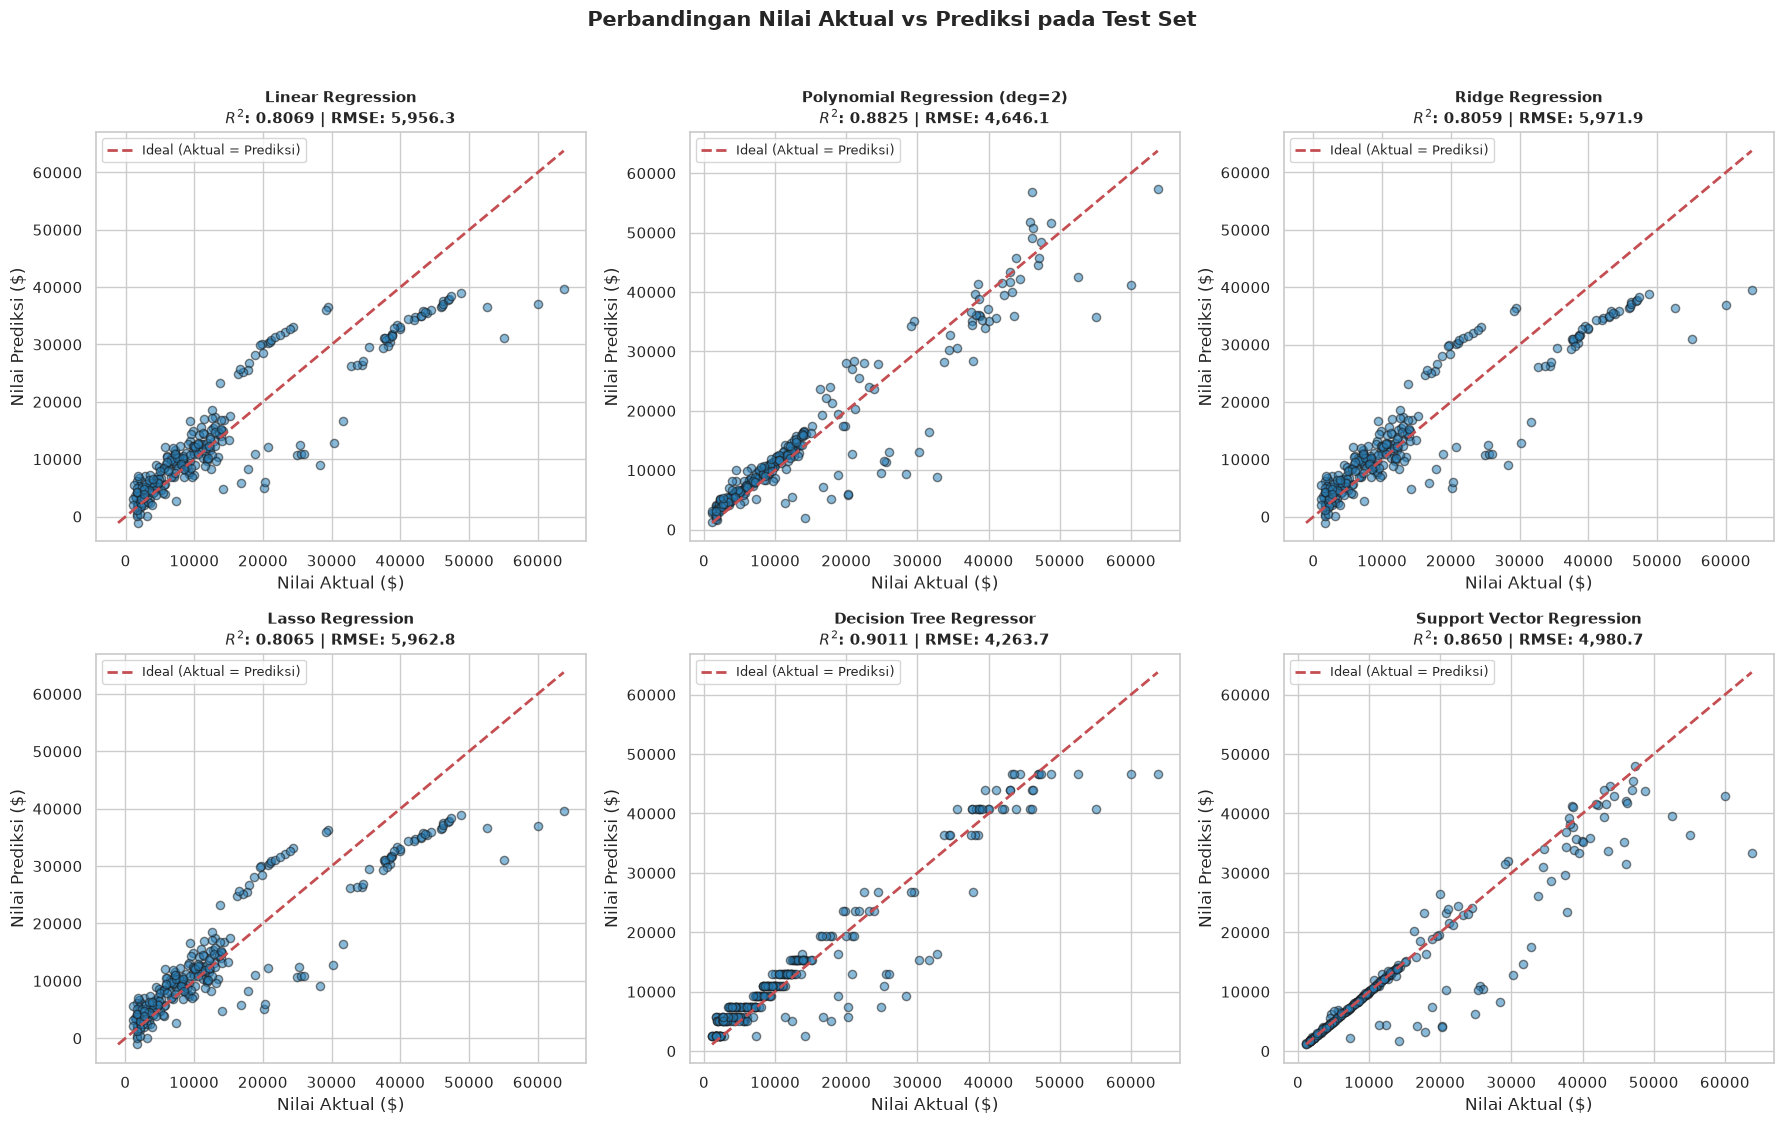

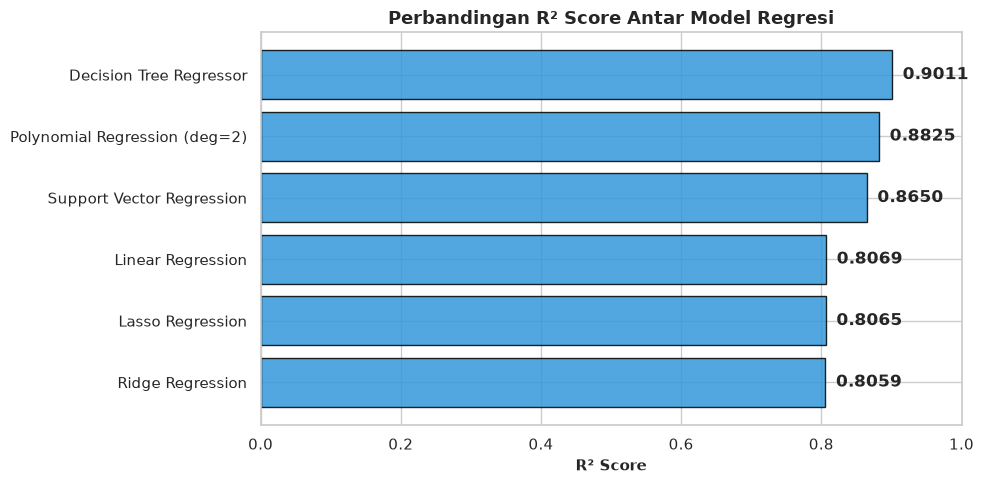

In [26]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (name, preds) in enumerate(model_predictions.items()):
    ax = axes[idx]
    # Scatter actual vs predicted
    ax.scatter(y_test, preds, alpha=0.55, color='#2980b9', edgecolors='k', s=35)
    # Garis sempurna y = x
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (Aktual = Prediksi)')
    
    r2_val = r2_score(y_test, preds)
    rmse_val = np.sqrt(mean_squared_error(y_test, preds))
    ax.set_title(f"{name}\n$R^2$: {r2_val:.4f} | RMSE: {rmse_val:,.1f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Nilai Aktual ($)")
    ax.set_ylabel("Nilai Prediksi ($)")
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle("Perbandingan Nilai Aktual vs Prediksi pada Test Set", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Visualisasi Bar Plot R² Score dan RMSE
fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.barh(eval_df['Model'], eval_df['R² Score'], color='#3498db', alpha=0.85, edgecolor='black')
ax1.set_xlabel('R² Score', fontweight='bold', fontsize=11)
ax1.set_xlim(0, 1.0)
ax1.set_title('Perbandingan R² Score Antar Model Regresi', fontweight='bold', fontsize=13)

for bar in bars:
    w = bar.get_width()
    ax1.text(w + 0.015, bar.get_y() + bar.get_height()/2, f'{w:.4f}', ha='left', va='center', fontweight='bold')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.

### Ringkasan Analisis:

**1. Perbandingan Kinerja Model:**
- **Decision Tree Regressor** ($R^2 = 0.9011$, RMSE = 4,263) dan **Polynomial Regression (Degree 2)** ($R^2 = 0.8825$, RMSE = 4,646) adalah dua model terbaik karena berhasil menangkap interaksi non-linear antara BMI (`bmi`) dan status merokok (`smoker`).
- **Support Vector Regression (SVR)** ($R^2 = 0.8650$) menghasilkan **MAE terendah (1,979.78)** berkat fungsi *$\epsilon$-insensitive loss* yang lebih kebal terhadap nilai ekstrem (outlier).
- **Linear, Lasso, dan Ridge Regression** memiliki performa yang praktis identik ($R^2 \approx 0.806$, RMSE $\approx 5,960$). Ketiganya terbatas karena mengasumsikan pola aditif linear sederhana.

**2. Pengaruh Preprocessing:**
- **One-Hot Encoding**: Diperlukan untuk merepresentasikan fitur kategori (`sex`, `smoker`, `region`) secara numerik; parameter `drop='first'` mencegah multikolinearitas (dummy variable trap).
- **Feature Scaling (StandardScaler)**: Wajib untuk SVR (perhitungan jarak kernel RBF) dan Ridge/Lasso (penalti koefisien). Sebaliknya, Decision Tree tidak terpengaruh oleh scaling karena pembagian cabang berbasis ambang batas (threshold).

**3. Pengaruh Parameter:**
- **Degree (Polynomial)**: Degree 2 optimal ($R^2 = 0.8825$). Degree 3 mulai overfitting (fitur melonjak ke 164 dan $R^2$ uji turun).
- **Alpha (Ridge & Lasso)**: Nilai $\alpha$ kecil ($\le 5$) optimal karena jumlah fitur sedikit; nilai $\alpha$ besar membuat model underfitting.
- **max_depth & min_samples_leaf (Decision Tree)**: Tanpa batasan kedalaman terjadi overfitting parah (train $R^2 = 1.000$, test $R^2 = 0.8194$). Pembatasan `max_depth=4` dan `min_samples_leaf=20` sukses menaikkan generalisasi hingga test $R^2 = 0.9011$.
- **C & $\epsilon$ (SVR)**: Nilai default $C=1$ gagal ($R^2 < 0$) karena skala tagihan medis sangat besar (ribuan dolar). Menyesuaikan $C=15000$ dan $\epsilon=50$ membuat SVR konvergen secara optimal.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.

### Kesimpulan:
1. **Model Terbaik**: **Decision Tree Regressor** (`max_depth=4`, `min_samples_leaf=20`) memberikan performa keseluruhan terbaik ($R^2 = 0.9011$, RMSE = 4,263.74), diikuti oleh **Polynomial Regression (degree=2)** ($R^2 = 0.8825$).
2. **Karakteristik Data**: Biaya medis sangat dipengaruhi efek interaksi non-linear (terutama perokok dengan BMI > 30), sehingga model non-linear unggul $\approx 10\%$ dibanding model linear.
3. **Pentingnya Regularisasi**: Membatasi kedalaman Decision Tree dan menaikkan nilai penalti $C$ pada SVR sangat penting untuk mencegah overfitting dan underfitting.
4. **Keunggulan SVR**: SVR menjadi pilihan terbaik jika fokus evaluasi adalah meminimalkan deviasi rata-rata (MAE terendah: 1,979.78).